# 04 — Momentum Oscillators: RSI and MACD

## What you'll learn
- What **momentum** means: not "how expensive", but *how fast* price is changing.
- **RSI** (Relative Strength Index): a 0–100 oscillator built from average gains vs losses.
- **MACD** (Moving Average Convergence Divergence): the gap between two EMAs, plus a signal line.
- How to read **overbought/oversold** and **crossovers**, and why overbought ≠ "sell".
- Why oscillators **whipsaw** in sideways markets, and what a **divergence** looks like.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

from stocklearn.data import get_history, price_series
from stocklearn.indicators import rsi, macd

# Swap this one symbol to analyse a different stock.
ticker = "AAPL"
period = "1y"


**One variable to swap.** Everything below uses `ticker` and `period`. Change them here and
re-run the notebook top to bottom — the whole analysis follows the new symbol.

## The idea behind momentum

Price tells you *where* the market is; momentum tells you *how fast it got there*. Two stocks can
both be at \$100, but one rose smoothly and the other spiked yesterday. Momentum indicators turn
that speed into a number, which is what lets us compare it across time and across stocks.

We use two classic oscillators:

| Indicator | Input | Output | Reads as |
|---|---|---|---|
| **RSI** | recent gains vs losses | 0–100 | overbought (>70) / oversold (<30) |
| **MACD** | two EMAs of price | two lines + histogram | trend acceleration & crossovers |


In [2]:
df = get_history(ticker, period=period)
close = price_series(df)

rsi_series = rsi(close, period=14)   # Wilder's RSI
print(df.index.min().date(), "to", df.index.max().date())
print("bars:", len(df))


2025-10-03 to 2026-10-02
bars: 251


## RSI — the Relative Strength Index

RSI compares the *average gain* to the *average loss* over the last `period` bars (Wilder's 14 is
the classic default):

$$ \text{RSI} = 100 - \frac{100}{1 + \frac{\text{avg gain}}{\text{avg loss}}} $$

The averages are **exponentially weighted** (`ewm(alpha=1/period)`), so recent moves count more
than old ones. A pure uptrend pushes RSI toward 100 (no losses to divide by); a pure downtrend
pushes it toward 0. Note it is **bounded** — that is what makes it an *oscillator*.


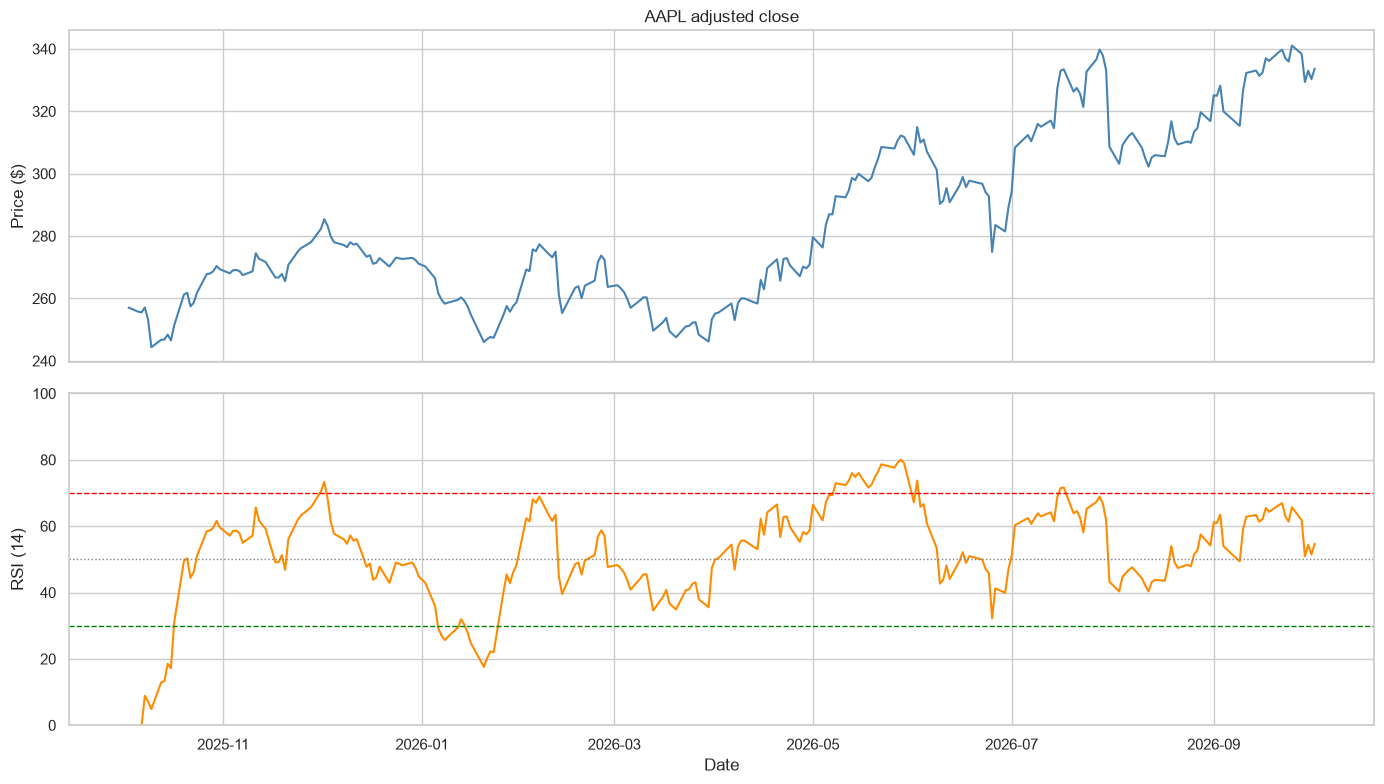

In [3]:
fig, (ax_price, ax_rsi) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax_price.plot(close.index, close, color="steelblue")
ax_price.set_title(f"{ticker} adjusted close")
ax_price.set_ylabel("Price ($)")

ax_rsi.plot(rsi_series.index, rsi_series, color="darkorange")
ax_rsi.axhline(70, color="red", linestyle="--", linewidth=1)
ax_rsi.axhline(30, color="green", linestyle="--", linewidth=1)
ax_rsi.axhline(50, color="grey", linestyle=":", linewidth=1)
ax_rsi.set_ylim(0, 100)
ax_rsi.set_ylabel("RSI (14)")
ax_rsi.set_xlabel("Date")

plt.tight_layout()
plt.show()


## Reading the latest RSI value

| Zone | RSI | Textbook meaning | What it does **not** mean |
|---|---|---|---|
| **Overbought** | > 70 | Buyers have been unusually aggressive recently; price rose fast. | It does **not** mean "sell". Strong trends can stay overbought for weeks. |
| **Neutral** | 30–70 | No extreme in recent up/down balance. | — |
| **Oversold** | < 30 | Sellers have been unusually aggressive recently; price fell fast. | It does **not** mean "buy". Falling knives stay oversold. |

**Why overbought ≠ sell:** RSI measures *speed*, not *value*. In a powerful uptrend, RSI can sit
above 70 for a long time while price keeps climbing. Treating every >70 reading as a sell signal
would have you exit strong trends early. RSI is best used to describe *condition* (stretched vs
calm) alongside trend and price structure — not as a standalone trigger.


In [4]:
last_rsi = float(rsi_series.iloc[-1])
if last_rsi > 70:
    zone = "overbought (> 70)"
elif last_rsi < 30:
    zone = "oversold (< 30)"
else:
    zone = "neutral (30–70)"

print(f"{ticker} latest RSI(14) = {last_rsi:.1f}  ->  {zone}")


AAPL latest RSI(14) = 54.7  ->  neutral (30–70)


## MACD — Moving Average Convergence Divergence

MACD is not bounded; it is built from two **exponential moving averages** of price:

- `macd` line = EMA(12) − EMA(26). Positive when short-term momentum is above long-term.
- `signal` line = EMA(9) of the `macd` line — a smoothed version of it.
- `hist` (histogram) = `macd` − `signal` — how far the fast line is ahead of its own average.

**Crossovers:** when `macd` crosses *above* `signal`, that is a **bullish** crossover (the
histogram flips from negative to positive). Crossing *below* is **bearish**. The histogram is
simply a visualisation of the gap between the two lines.


In [5]:
macd_df = macd(close, fast=12, slow=26, signal=9)
macd_df.tail()


,macd,signal,hist
Date,,,
2026-09-28 00:00:00-04:00,6.096411,5.566718,0.529693
2026-09-29 00:00:00-04:00,5.204299,5.494234,-0.289935
2026-09-30 00:00:00-04:00,4.734817,5.342351,-0.607534
2026-10-01 00:00:00-04:00,4.097648,5.093410,-0.995762
2026-10-02 00:00:00-04:00,3.820576,4.838843,-1.018267


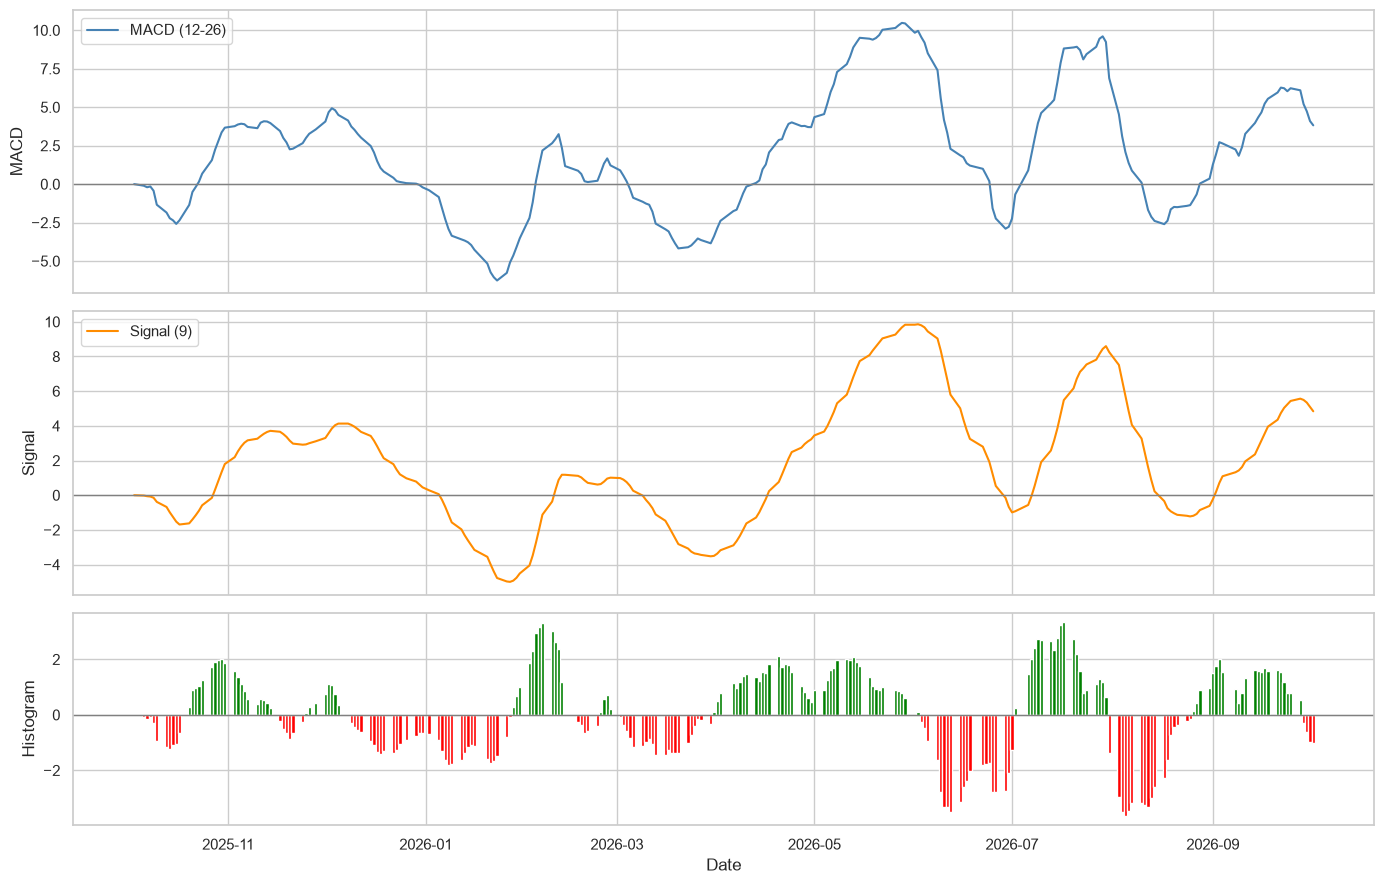

In [6]:
fig, (ax_macd, ax_sig, ax_hist) = plt.subplots(
    3, 1, figsize=(14, 9), sharex=True,
    gridspec_kw={"height_ratios": [2, 2, 1.5]},
)

ax_macd.plot(macd_df.index, macd_df["macd"], color="steelblue", label="MACD (12-26)")
ax_macd.axhline(0, color="grey", linewidth=1)
ax_macd.set_ylabel("MACD")
ax_macd.legend(loc="upper left")

ax_sig.plot(macd_df.index, macd_df["signal"], color="darkorange", label="Signal (9)")
ax_sig.axhline(0, color="grey", linewidth=1)
ax_sig.set_ylabel("Signal")
ax_sig.legend(loc="upper left")

colors = np.where(macd_df["hist"] > 0, "green", "red")
ax_hist.bar(macd_df.index, macd_df["hist"], color=colors, width=1.0)
ax_hist.axhline(0, color="grey", linewidth=1)
ax_hist.set_ylabel("Histogram")
ax_hist.set_xlabel("Date")

plt.tight_layout()
plt.show()


## Locating crossovers

A crossover is a **sign change of the histogram**. In pandas we detect it with boolean masks on
the current bar and the previous bar (`.shift(1)`):

- bullish: `hist > 0` **and** `hist.shift(1) <= 0`
- bearish: `hist < 0` **and** `hist.shift(1) >= 0`

The first valid bar is always NaN after `shift`, so it never fires spuriously. We then mark those
dates on the MACD line with `scatter`.


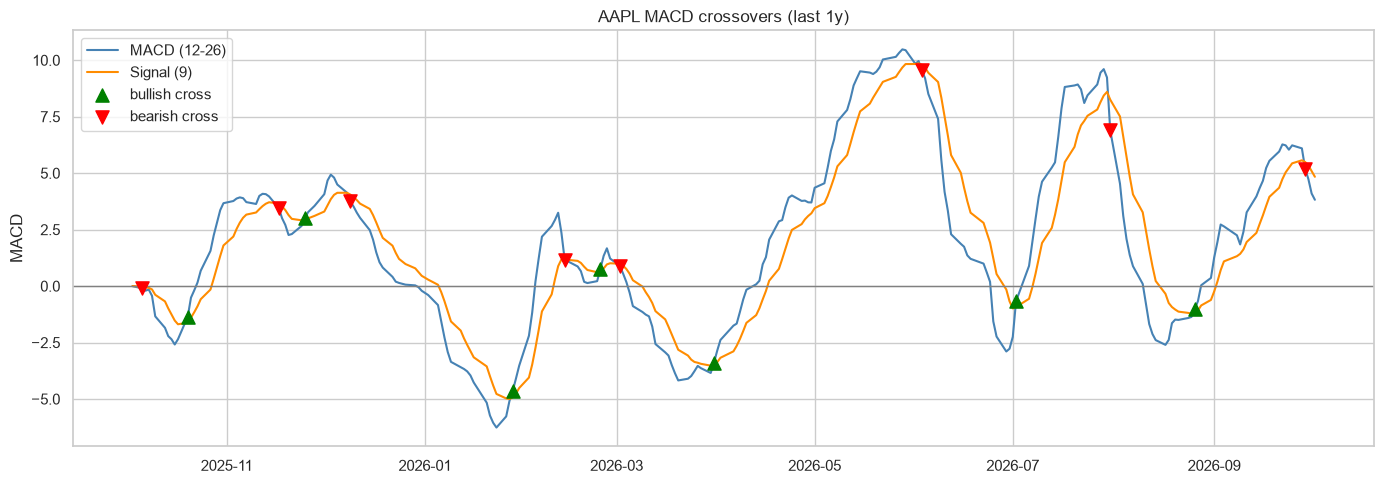

bullish crossovers: 7
bearish crossovers: 8


In [7]:
hist = macd_df["hist"]
bull_cross = (hist > 0) & (hist.shift(1) <= 0)
bear_cross = (hist < 0) & (hist.shift(1) >= 0)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(macd_df.index, macd_df["macd"], color="steelblue", label="MACD (12-26)")
ax.plot(macd_df.index, macd_df["signal"], color="darkorange", label="Signal (9)")
ax.axhline(0, color="grey", linewidth=1)

ax.scatter(macd_df.index[bull_cross], macd_df["macd"][bull_cross],
           marker="^", s=90, color="green", zorder=5, label="bullish cross")
ax.scatter(macd_df.index[bear_cross], macd_df["macd"][bear_cross],
           marker="v", s=90, color="red", zorder=5, label="bearish cross")

ax.set_title(f"{ticker} MACD crossovers (last {period})")
ax.set_ylabel("MACD")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

print("bullish crossovers:", int(bull_cross.sum()))
print("bearish crossovers:", int(bear_cross.sum()))


## Whipsaws and divergence

**Whipsaw** — oscillators are trend-following *and* range-bound at the same time, which is their
weakness. In a sideways market price chops back and forth, so RSI repeatedly pings between 30 and
70 and MACD crosses back and forth, generating many signals that quickly cancel out. That is why
crossovers are far more reliable when a real trend is in place, and why traders often filter them
(for example, only act on bullish crosses when price is above a rising 200-day SMA).

**Divergence** describes a disagreement between price and momentum, and it is *read*, not computed:

- **Bearish divergence:** price makes a **higher high**, but RSI (or the MACD line) makes a
  **lower high**. Price is rising on weakening momentum — often a warning that the advance is
  tiring.
- **Bullish divergence:** price makes a **lower low**, but RSI (or the MACD line) makes a
  **higher low**. Selling is losing force even as price falls.

Spotting divergence means comparing two peaks/troughs by eye. It is a classic pattern-recognition
skill, not a formula, and it is easy to see patterns that aren't there — so treat it as context,
never as a mechanical signal.


## Recap / try this
- Swap `ticker = "MSFT"` (or your own symbol) and re-run: does MSFT's RSI sit in the same zone?
- Change the RSI window to `rsi(close, period=7)` and compare — shorter period = jumpier oscillator.
- Plot `macd(close, fast=5, slow=35, signal=5)` and see how slower settings smooth out crossovers.
- Zoom into a stretch where price went sideways and count the MACD crosses; that is a whipsaw.
- Look for a bearish divergence by eye: find a price higher high whose RSI peak is lower.
